# The Mechanism of Learning

From the point of view of an observer, a learning is presented with input data that is paired with desired outputs. Once learning has occurred, that algorithm will be capable of producing correct outputs when it is fed new data that is **similar enough** to the input data it was trained on.

One interesting way to look at the learning problem is to look at it through the lens of parameter estimation.  
Let's show it using linear model example:

In [1]:
import torch

In [18]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

In [19]:
import seaborn as sb

<Axes: xlabel='None', ylabel='None'>

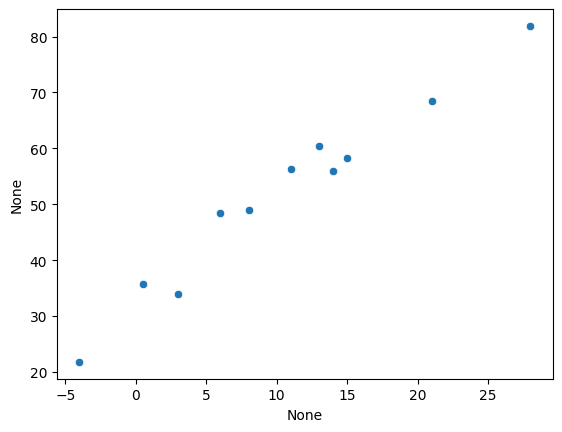

In [21]:
sb.scatterplot(x=t_c, y=t_u)

We have a model with some unknown parameters, and we need to estimate those parameters so that the error between predicted outputs and measured values is as low as possible. We notice that we still need to exactly define a measure of the error. Such a measure, which we refer to as the **loss function**, should be high if the error is high and should ideally be as low as possible for a perfect match.

A *loss function* (or cost function) is a function that computes a single numerical value that the learning process will attempt to minimize. We need a loos function to be convex.

In [22]:
# Define a linear model.
def model(t_u, w, b):
    return w * t_u + b

In [23]:
# Define a smooth, convex loss function
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

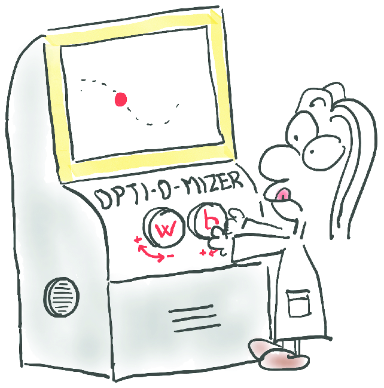


In [64]:
# For example, I guess random values for w and b and check the loss:
w = 0.12
b = 5.3
pred = model(t_u, w, b)
loss = loss_fn(pred, t_c)
print(loss)

tensor(48.6975)


# PyTorch’s autograd